In [2]:
import tensorflow as tf
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.applications import EfficientNetB0

2025-03-30 15:29:32.430064: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-30 15:29:32.430567: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 15:29:32.432909: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 15:29:32.440083: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743328772.452538   24987 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743328772.45

In [3]:
conv_base = EfficientNetB0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (128,128,3)
)

2025-03-12 22:49:18.629608: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
plant_model = Sequential()
plant_model.add(conv_base)
plant_model.add(Flatten())
plant_model.add(Dense(17, activation='softmax'))

In [5]:
conv_base.trainable = False

In [6]:
plant_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 17)             │       348,177 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,397,748 (16.78 MB)

 Trainable params: 348,177 (1.33 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [3]:
dataset = keras.preprocessing.image_dataset_from_directory(
    directory='./Dataset/Leaf',
    shuffle=True,
    batch_size = 16,
    image_size = (128,128)
)

Found 64348 files belonging to 17 classes.


2025-03-30 15:29:45.391218: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
class_names = dataset.class_names
print(class_names)

['Apple', 'Bell Pepper', 'Cherry', 'Corn', 'Cucumber', 'Grape', 'Guava', 'Lemon', 'Mango', 'Peach', 'Potato', 'Rice', 'Strawberry', 'Sugarcane', 'Tea', 'Tomato', 'Wheat']


In [5]:
size = dataset.cardinality().numpy()

In [6]:
train_ds = dataset.take(int(size*0.7))
valid_ds = dataset.skip(int(size*0.7)).take(int(size*0.2))
test_ds = dataset.skip(int(size*0.9))

In [7]:
print(train_ds.cardinality())
print(valid_ds.cardinality())
print(test_ds.cardinality())

tf.Tensor(2815, shape=(), dtype=int64)
tf.Tensor(804, shape=(), dtype=int64)
tf.Tensor(403, shape=(), dtype=int64)


In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
plant_model.compile(
    optimizer = 'adam',
    metrics = ['accuracy'],
    loss = 'sparse_categorical_crossentropy'
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

In [15]:
history = plant_model.fit(
    train_ds,
    validation_data = valid_ds,
    epochs = 50,
    callbacks=callbacks
)

Epoch 1/50


2025-03-12 22:49:36.202890: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 689 of 1000
2025-03-12 22:49:40.817382: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


2815/2815 ━━━━━━━━━━━━━━━━━━━━ 389s 131ms/step - accuracy: 0.9225 - loss: 0.3732 - val_accuracy: 0.9789 - val_loss: 0.1806
Epoch 2/50
2815/2815 ━━━━━━━━━━━━━━━━━━━━ 292s 104ms/step - accuracy: 0.9801 - loss: 0.1275 - val_accuracy: 0.9758 - val_loss: 0.2723
Epoch 3/50
2815/2815 ━━━━━━━━━━━━━━━━━━━━ 313s 111ms/step - accuracy: 0.9874 - loss: 0.0991 - val_accuracy: 0.9758 - val_loss: 0.3013
Epoch 4/50
2815/2815 ━━━━━━━━━━━━━━━━━━━━ 312s 111ms/step - accuracy: 0.9891 - loss: 0.0889 - val_accuracy: 0.9806 - val_loss: 0.2694
Epoch 5/50
2815/2815 ━━━━━━━━━━━━━━━━━━━━ 301s 107ms/step - accuracy: 0.9898 - loss: 0.0880 - val_accuracy: 0.9778 - val_loss: 0.3609
Epoch 6/50
2815/2815 ━━━━━━━━━━━━━━━━━━━━ 298s 106ms/step - accuracy: 0.9923 - loss: 0.0719 - val_accuracy: 0.9855 - val_loss: 0.2810


In [16]:
plant_model.save('../saved_models/plant_model.keras')

In [17]:
plant_model.evaluate(test_ds)

403/403 ━━━━━━━━━━━━━━━━━━━━ 95s 84ms/step - accuracy: 0.9787 - loss: 0.1965


[0.19281615316867828, 0.9764121770858765]

In [9]:
plant_model=keras.models.load_model('../saved_models/plant_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
[7.96583058e-22 1.12412547e-28 1.26839552e-19 1.60850556e-19
 9.00143557e-22 9.99999881e-01 1.92933983e-36 1.38749005e-36
 1.60395102e-29 1.08558044e-23 1.61356083e-22 4.82877431e-30
 1.91815883e-10 1.16199178e-29 3.53973761e-24 6.54773729e-08
 1.19981228e-34]
Actual label:  Grape
Predicted label:  Grape


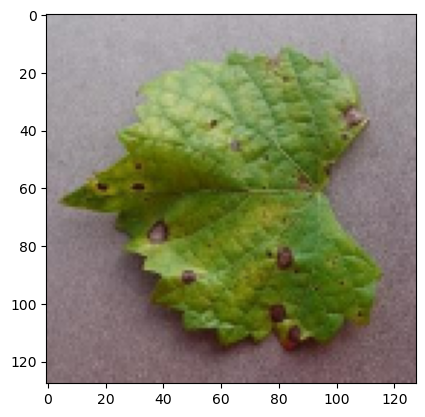

In [15]:
import numpy as np
import matplotlib.pyplot as plt

for image_batch, label_batch in test_ds.shuffle(buffer_size=1000).take(1):
    image = image_batch[0].numpy().astype('uint8')
    label = label_batch[0]

    plt.imshow(image)

    batch_pred = plant_model.predict(image_batch)
    print(batch_pred[0])
    print("Actual label: ",class_names[label])
    print("Predicted label: ", class_names[np.argmax(batch_pred[0])])